# 2024-11-01 What the photometry program did

## Overview

+ Explain what the "annulus" is in aperture photometry
+ Look at an example of an aperture with an annulus
+ Choose comparison stars for your object

In [28]:
from astropy.modeling.models import Gaussian2D
from astropy.stats import gaussian_sigma_to_fwhm

from matplotlib import pyplot as plt

import numpy as np

from photutils.profiles import RadialProfile, CurveOfGrowth
from photutils.aperture import CircularAperture, CircularAnnulus

In [29]:
def image_with_pixels_labeled(image, pix_precision=0, center_dots=True, ax=None, fig=None, **text_kwargs):
    image_size = image.shape[0]
    if ax is None:
        ax = plt.gca()
    if fig is not None:
        fig = plt.gcf()
    ima = ax.imshow(image)
    if fig is not None:
        fig.colorbar(ima, ax=ax)
    number_format = '{:.' + f'{pix_precision:d}' + 'f}'
    for i in range(image_size):
        for j in range(image_size):
            ax.text(i, j, number_format.format(image[j, i]),
                     fontweight='bold',
                     horizontalalignment='center',
                     verticalalignment='center',
                     **text_kwargs
                    )
            if center_dots:
                ax.scatter(i, j, marker='.', c='red', alpha=0.5)


In [30]:
def circle(x, y, radius):
    angle = np.linspace(0, 2 * np.pi)
    return x + radius * np.cos(angle), y + radius * np.sin(angle)

In [31]:
rng = np.random.default_rng()

In [32]:
figure_size = (10, 10)
graph_size = (10, 10)
image_size = 25
star_center = (12, 12)
background_center = 200
sigma = 2  # Gaussian width of the star
background_image = rng.poisson(lam=background_center, size=[image_size, image_size])

In [33]:

fwhm = sigma * gaussian_sigma_to_fwhm

star = Gaussian2D(amplitude=200, x_stddev=sigma, y_stddev=sigma)
grids = np.mgrid[0:image_size, 0:image_size]
star_grid = star(grids[0] - star_center[0], grids[1] - star_center[1])

In [34]:
total_image = background_image + star_grid

In [35]:
new_background_image = rng.poisson(lam=200, size=[image_size, image_size])
new_total_image = new_background_image + star_grid

In [36]:
ap_rad = np.round(fwhm)
gap = 2
annul_width = 3
aperture = CircularAperture(star_center, ap_rad)
annul = CircularAnnulus(star_center, ap_rad + gap, ap_rad + gap + annul_width)

### Step-by-step

1. For every star of interest in the image (the red and blue dots in notebook 2), do this:
    1. Draw a circle around it and add up the counts inside the circle. You set the radius of the circle in notebook 2.
    3. Estimate the average background using an *annulus* around the star
    4. Calculate the net counts due to the star
    5. Calculate the *instrumental magnitude* of the star
1. Repeat until all stars are done

### Aperture with an annulus

The pixels in the donut-shaped annulus are used to estimate the background.

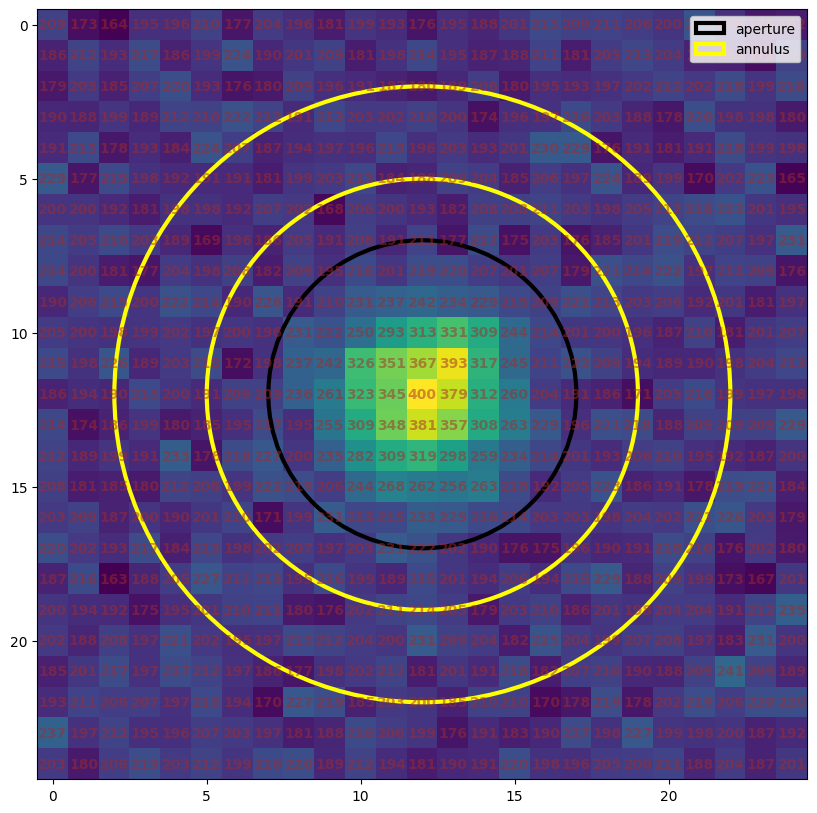

In [37]:
fig = plt.figure(figsize=figure_size)


image_with_pixels_labeled(new_total_image, color='brown', center_dots=False, alpha=0.5)
aperture.plot(linewidth=3, label='aperture')
annul.plot(linewidth=3, color='yellow', label='annulus')
plt.legend(loc='upper right')

## Overview

From last time, you have measuresments of the brightness of the stars in your color image.

Today we will talk about how to remove the effects of the atmosphere and our instruments on those measurements.

<!-- ![Sketch of atmospheric and intrumental effects](media/AST-266-27.jpg) -->

## Color-magnitude diagram...maybe an HR diagram?

In [ ]:
from pathlib import Path
import numpy as np

from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import Table

from astroquery.gaia import Gaia

from stellarphot import PhotometryData
from ipyautoui.custom import FileChooser

%matplotlib inline
import matplotlib.pyplot as plt

#### Choose your photometry file (should be called `photometry.ecsv')

In [ ]:
chooser = FileChooser(filter_pattern=["*.ecsv"])
chooser


In [ ]:
your_mag_table = chooser.value

In [ ]:
mag_table = PhotometryData.read(your_mag_table)

In [ ]:
B = mag_table[mag_table['passband'] == 'B']
V = mag_table[mag_table['passband'] == 'V']

In [ ]:
mag_col = 'mag_inst'
# fig, resid = plt.subplots(1, 1, figsize=(10, 10))

# resid.plot(B['color_cat'], B['color_cat'] - (B[mag_col] - V[mag_col]), '.', label='catalog colors', alpha=0.4)
# #plt.ylim(16.5, 10)
# resid.set_xlabel('Catalog B-V')
# resid.set_ylabel('Diff between catalog and calibrated B-V')
# resid.set_title(your_mag_table)
# resid.grid()

In [ ]:
good_color = np.abs(B[mag_col]) > -1  # B['color_cat'] - (B['mag_inst_cal'] - V['mag_inst_cal'])) < 0.1

In [ ]:
fig, cmd = plt.subplots(1, 1, figsize=(5, 5))

cmd.plot(B[mag_col][good_color] - V[mag_col][good_color], V[mag_col][good_color], '.')
cmd.set_ylim(*cmd.get_ylim()[::-1])
cmd.set_ylabel('V')
cmd.set_xlabel('B - V')
cmd.set_xlim(-0.5, 2.5)
cmd.set_xlabel("Color (B-V instrumental)")
cmd.set_ylabel("Magnitude (V instrumental")
cmd.set_title("Color-magnitude diagram (???)")
cmd.grid()


## Atmospheric and instrumental effects

Discussion on the ipad....

<!-- ![Sketch of atmospheric and intrumental effects](media/AST-266-26.jpg) -->